# Qwen2.5-0.5B-coder Fine-Tuning
### Fine-tuning `unsloth/Qwen2.5-Coder-0.5B-Instruct-bnb-4bit`

## 1. Install Dependencies

In [1]:
!pip install torch transformers datasets accelerate peft bitsandbytes \
            huggingface_hub evaluate safetensors sentence-transformers \
            unsloth_zoo sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.4 MB/s eta 0:00:00
  Cr

In [2]:
!pip install git+https://github.com/unslothai/unsloth.git

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-req-build-7si2y4o6
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-req-build-7si2y4o6
  Resolved https://github.com/unslothai/unsloth.git to commit f7bd05ad13255dba07112056c15e966819bc9a2a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.5.2-py3-none-any.whl size=34225067 sha256=54b536ce336b28ef14fce24b26424d001e5c11e67f90c4a71cb732057eb18b2e
  Stored in directory: /tmp/pip-ephem-wheel-cache-r0yb1b0y/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built unsloth


## 2. Import Libraries

In [3]:
import torch
import numpy as np
from unsloth import FastLanguageModel, is_bfloat16_supported
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns
import random

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## 3. Load Base Model & Tokenizer

In [4]:
max_seq_length = 2048
dtype          = None
load_in_4bit   = True
Base_Model     = "unsloth/Qwen2.5-Coder-0.5B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=Base_Model,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": tokenizer.eos_token})

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/457M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

## 4. Apply LoRA Adapters

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.2 patched 24 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


## 5. Load & Split Dataset

In [6]:
dataset = load_dataset("ise-uiuc/Magicoder-OSS-Instruct-75K")
print(dataset)

README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data-oss_instruct-decontaminated.jsonl:   0%|          | 0.00/203M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75197 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['lang', 'raw_index', 'index', 'seed', 'openai_fingerprint', 'problem', 'solution'],
        num_rows: 75197
    })
})


In [7]:
full_dataset = dataset["train"].shuffle(seed=42)

TRAIN_SIZE = 70000
EVAL_SIZE = 1500
TEST_SIZE = 70

train_dataset = full_dataset.select(range(0, TRAIN_SIZE))

eval_dataset = full_dataset.select(
    range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE)
)

test_dataset = full_dataset.select(
    range(TRAIN_SIZE + EVAL_SIZE,
          TRAIN_SIZE + EVAL_SIZE + TEST_SIZE)
)

In [8]:
eval_dataset[0]

{'lang': 'cpp',
 'raw_index': 90240,
 'index': 2229,
 'seed': '#include <lmdb.h>\n#include <memory>\n#include <string>\n#include <optional>\n\nnamespace lmdb {\n\nclass env {\npublic:\n    class deleter;\n    class factory;\n    enum class flags : unsigned int {\n',
 'openai_fingerprint': 'fp_eeff13170a',
 'problem': 'You are tasked with implementing a simplified version of a key-value store using the LMDB (Lightning Memory-Mapped Database) library. The LMDB library provides a high-performance embedded transactional key-value store, and in this problem, we will focus on creating a basic key-value store using LMDB.\n\nYour task is to implement a C++ class called `KeyValueStore` that provides methods to store and retrieve key-value pairs using LMDB. The class should have the following public methods:\n1. `open(const std::string& path)`: Opens or creates an LMDB environment at the specified `path`.\n2. `put(const std::string& key, const std::string& value)`: Inserts a key-value pair into 

## 7. Apply Chat Template to Train & Eval Datasets

In [9]:
custom_system_message = "I am cortex your coding assistant made by junaid"

def format_chat(example):
    messages = [
        {"role": "system", "content": custom_system_message},
        {"role": "user", "content": example["problem"]},
        {"role": "assistant", "content": example["solution"]},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    return {"text": text}


train_dataset = train_dataset.map(format_chat)
eval_dataset = eval_dataset.map(format_chat)
test_dataset = test_dataset.map(format_chat)


print(train_dataset[0]["text"])

Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

<|im_start|>system
I am cortex your coding assistant made by junaid<|im_end|>
<|im_start|>user
You are tasked with creating a program that generates a simple line plot using the matplotlib library in Python. The plot should represent a sine wave with a specific frequency and amplitude. Your program should allow the user to input the frequency and amplitude of the sine wave and then display the plot with appropriate labels and grid lines.

Your program should follow these requirements:
- Prompt the user to input the frequency and amplitude of the sine wave.
- Use the matplotlib library to create a line plot of a sine wave with the given frequency and amplitude.
- Label the x-axis as "Tempo" and the y-axis as "Amplitude".
- Display grid lines on the plot.
- Present the plot to the user.

Your program should not require any additional input once the frequency and amplitude are provided.<|im_end|>
<|im_start|>assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Prompt 

## 8. Configure SFTTrainer & Training Arguments

In [10]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    tokenizer=tokenizer,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=1, # Reduced from 2 to 1 to save memory
        gradient_accumulation_steps=4,
        warmup_ratio=0.03,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        tf32=False,
        max_steps=120,
        logging_steps=5,
        output_dir="outputs",
        optim="adamw_8bit",
        weight_decay=0.05,
        lr_scheduler_type="linear",
        seed=3407,
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/70000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1500 [00:00<?, ? examples/s]

## 9. Train the Model

In [11]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 70,000 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 17,596,416 of 511,629,184 (3.44% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.179496
10,0.935729
15,0.771348
20,0.712263
25,0.709115
30,0.591228
35,0.697463
40,0.591213
45,0.582637
50,0.701575


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-120/tokenizer_config.json.


## 10. Save LoRA Adapter

In [12]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

Unsloth: Restored added_tokens_decoder metadata in lora_model/tokenizer_config.json.


('lora_model/tokenizer_config.json',
 'lora_model/chat_template.jinja',
 'lora_model/tokenizer.json')

## 11. Evaluation
### Comparing Base Model vs Fine-Tuned Model using Perplexity, BLEU, and ROUGE

We evaluate on `test_dataset` (raw, unformatted) which the model has never seen during training.

In [13]:
# Base model
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=Base_Model,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

FastLanguageModel.for_inference(base_model)

# Fine-tuned model
ft_model, _ = FastLanguageModel.from_pretrained(
    model_name="lora_model",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

FastLanguageModel.for_inference(ft_model)

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896, padding_idx=151665)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
             

# Prepare evaluation data

In [14]:
N_EVAL = 50

test_raw = test_dataset.select(range(N_EVAL))

prompts = []
references = []
ppl_texts = []

for example in test_raw:

    # The 'instruction' field contains the user's prompt content
    instruction_content = example["problem"]
    # The 'output' field contains the assistant's reference answer
    reference_answer = example["solution"]
    # The 'text' field contains the full chat formatted for perplexity calculation
    full_text_for_perplexity = example["text"]

    # Construct the prompt for generation: only the user's instruction, formatted with add_generation_prompt=True
    prompt_messages_for_generation = [
        {"role": "system", "content": custom_system_message},
        {"role": "user", "content": instruction_content}
    ]
    prompt = tokenizer.apply_chat_template(
        prompt_messages_for_generation,
        tokenize=False,
        add_generation_prompt=True
    )

    prompts.append(prompt)
    references.append(reference_answer)
    ppl_texts.append(full_text_for_perplexity)

print(f"Prepared {len(prompts)} evaluation samples.")

print("\n── Sample Prompt ──\n")
print(prompts[0][:1000])

print("\n── Sample Reference ──\n")
print(references[0][:500])

Prepared 50 evaluation samples.

── Sample Prompt ──

<|im_start|>system
I am cortex your coding assistant made by junaid<|im_end|>
<|im_start|>user
You are tasked with creating a Python class to manage employees in an organization. The class should have the following functionalities:

1. Initialize the employee with their details.
2. Allow the manager to input a list of employees under them.
3. Display the details of the manager and the employees under them.

You are provided with a partial code snippet for the `Employee` class, which includes an `__init__` method and a `display2` method. Your task is to complete the `Employee` class by implementing the missing methods and ensuring that the class functions as described.

Complete the `Employee` class by adding the following methods:
- `__init__`: Initialize the employee with their name, ID, and department.
- `display`: Display the details of the manager, including their name, ID, and department.
- `input_emp_under`: Allow the manager 

### 12. Perplexity

In [15]:
def compute_perplexity(model, tokenizer, texts, max_len=2048):

    model.eval()

    losses = []

    with torch.no_grad():

        for text in texts:

            enc = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_len
            ).to(model.device)

            outputs = model(
                **enc,
                labels=enc["input_ids"]
            )

            losses.append(outputs.loss.item())

    ppl = np.exp(np.mean(losses))

    return round(float(ppl), 2)


base_ppl = compute_perplexity(
    base_model,
    tokenizer,
    ppl_texts
)

ft_ppl = compute_perplexity(
    ft_model,
    tokenizer,
    ppl_texts
)

print(f"Base model PPL : {base_ppl}")
print(f"Fine-tuned PPL : {ft_ppl}")

print(
    f"Improvement : "
    f"{round((base_ppl - ft_ppl) / base_ppl * 100, 1)}%"
)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Base model PPL : 3.58
Fine-tuned PPL : 1.98
Improvement : 44.7%


### 13. BLEU & ROUGE

In [16]:
def generate(model, tokenizer, prompt, max_new=128):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    prediction = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    return prediction.strip()

print("Generating base model predictions...")
base_preds = [
    generate(base_model, tokenizer, p)
    for p in prompts
]

print("Generating fine-tuned model predictions...")
ft_preds = [
    generate(ft_model, tokenizer, p)
    for p in prompts
]

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating base model predictions...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1

Generating fine-tuned model predictions...


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

In [17]:
bleu = BLEU()

base_bleu = bleu.corpus_score(
    base_preds,
    [references]
).score

ft_bleu = bleu.corpus_score(
    ft_preds,
    [references]
).score

print(f"\nBLEU base={base_bleu:.2f}")
print(f"BLEU fine-tuned={ft_bleu:.2f}")


BLEU base=13.98
BLEU fine-tuned=24.55


In [18]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=True
)

def avg_rouge(preds, refs):

    r1_scores = []
    rL_scores = []

    for pred, ref in zip(preds, refs):

        scores = rouge.score(ref, pred)

        r1_scores.append(
            scores["rouge1"].fmeasure
        )

        rL_scores.append(
            scores["rougeL"].fmeasure
        )

    return (
        round(sum(r1_scores) / len(r1_scores), 4),
        round(sum(rL_scores) / len(rL_scores), 4),
    )

base_r1, base_rL = avg_rouge(
    base_preds,
    references
)

ft_r1, ft_rL = avg_rouge(
    ft_preds,
    references
)

print(f"ROUGE-1 base={base_r1}")
print(f"ROUGE-1 fine-tuned={ft_r1}")

print(f"ROUGE-L base={base_rL}")
print(f"ROUGE-L fine-tuned={ft_rL}")

ROUGE-1 base=0.4454
ROUGE-1 fine-tuned=0.5315
ROUGE-L base=0.2718
ROUGE-L fine-tuned=0.4391


# Final Summary Table

In [19]:
print("\n" + "─" * 60)

print(
    f"{'Metric':<15}"
    f"{'Base':>12}"
    f"{'Fine-tuned':>15}"
    f"{'Result':>15}"
)

print("─" * 60)

metrics = [
    ("PPL ↓", base_ppl, ft_ppl, True),
    ("BLEU ↑", base_bleu, ft_bleu, False),
    ("ROUGE-1 ↑", base_r1, ft_r1, False),
    ("ROUGE-L ↑", base_rL, ft_rL, False),
]

for metric, base_v, ft_v, lower_better in metrics:

    improved = (
        ft_v < base_v
        if lower_better
        else ft_v > base_v
    )

    result = (
        "✓ improved"
        if improved
        else "✗ regressed"
    )

    print(
        f"{metric:<15}"
        f"{base_v:>12.4f}"
        f"{ft_v:>15.4f}"
        f"{result:>15}"
    )

print("─" * 60)


────────────────────────────────────────────────────────────
Metric                 Base     Fine-tuned         Result
────────────────────────────────────────────────────────────
PPL ↓                3.5800         1.9800     ✓ improved
BLEU ↑              13.9831        24.5515     ✓ improved
ROUGE-1 ↑            0.4454         0.5315     ✓ improved
ROUGE-L ↑            0.2718         0.4391     ✓ improved
────────────────────────────────────────────────────────────


In [20]:
def generate_k_samples(model, tokenizer, prompt, k=3, max_new=128, temperature=0.7, top_k=50):
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    # Generate k samples using sampling
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new,
            do_sample=True,  # Enable sampling
            temperature=temperature, # Set temperature for creativity
            top_k=top_k,        # Use top_k sampling
            num_return_sequences=k,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode all k generated predictions
    k_predictions = []
    for i in range(k):
        prediction = tokenizer.decode(
            outputs[i][inputs.input_ids.shape[1]:],
            skip_special_tokens=True
        )
        k_predictions.append(prediction.strip())
    return k_predictions

# Define k and a ROUGE-L threshold for a "pass"
K_SAMPLES = 3 # Number of samples to generate for each prompt
ROUGE_L_PASS_THRESHOLD = 0.5 # ROUGE-L F1 score threshold to consider a sample "passing"
MAX_NEW_TOKENS_FOR_PASS_AT_K = 256 # Increase max_new_tokens for potentially longer code responses

print(f"Running Pass@{K_SAMPLES} evaluation with ROUGE-L F1 threshold of {ROUGE_L_PASS_THRESHOLD}...")

base_passes = 0
ft_passes = 0

# The 'rouge' scorer is already initialized from previous cells

for i, prompt in enumerate(prompts):
    reference = references[i]

    # Evaluate Base Model
    base_k_preds = generate_k_samples(base_model, tokenizer, prompt, k=K_SAMPLES, max_new=MAX_NEW_TOKENS_FOR_PASS_AT_K)
    for pred in base_k_preds:
        scores = rouge.score(reference, pred)
        if scores["rougeL"].fmeasure >= ROUGE_L_PASS_THRESHOLD:
            base_passes += 1
            break # If at least one passes, this problem counts as a pass for the base model

    # Evaluate Fine-tuned Model
    ft_k_preds = generate_k_samples(ft_model, tokenizer, prompt, k=K_SAMPLES, max_new=MAX_NEW_TOKENS_FOR_PASS_AT_K)
    for pred in ft_k_preds:
        scores = rouge.score(reference, pred)
        if scores["rougeL"].fmeasure >= ROUGE_L_PASS_THRESHOLD:
            ft_passes += 1
            break # If at least one passes, this problem counts as a pass for the fine-tuned model

num_problems = len(prompts)
base_pass_at_k = (base_passes / num_problems) * 100
ft_pass_at_k = (ft_passes / num_problems) * 100

print(f"\nBase Model Pass@{K_SAMPLES}: {base_pass_at_k:.2f}% ({base_passes}/{num_problems} problems passed)")
print(f"Fine-tuned Model Pass@{K_SAMPLES}: {ft_pass_at_k:.2f}% ({ft_passes}/{num_problems} problems passed)")

print(
    f"\nPass@{K_SAMPLES} Improvement: "
    f"{round(ft_pass_at_k - base_pass_at_k, 2)}% points"
)

print("\n" + "─" * 60)

print(
    f"{'Metric':<15}"
    f"{'Base':>12}"
    f"{'Fine-tuned':>15}"
    f"{'Result':>15}"
)

print("─" * 60)

metrics.append(("Pass@K ↑", base_pass_at_k / 100, ft_pass_at_k / 100, False)) # Convert to ratio for consistent display

for metric_name, base_v, ft_v, lower_better in metrics:

    improved = (
        ft_v < base_v
        if lower_better
        else ft_v > base_v
    )

    result = (
        "✓ improved"
        if improved
        else "✗ regressed"
    )

    # Special formatting for percentage if it's Pass@K
    if "Pass@K" in metric_name:
        print(
            f"{metric_name:<15}"
            f"{base_v:>11.2%}"
            f"{ft_v:>14.2%}"
            f"{result:>15}"
        )
    else:
        print(
            f"{metric_name:<15}"
            f"{base_v:>12.4f}"
            f"{ft_v:>15.4f}"
            f"{result:>15}"
        )

print("─" * 60)

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Pass@3 evaluation with ROUGE-L F1 threshold of 0.5...


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


Base Model Pass@3: 14.00% (7/50 problems passed)
Fine-tuned Model Pass@3: 56.00% (28/50 problems passed)

Pass@3 Improvement: 42.0% points

────────────────────────────────────────────────────────────
Metric                 Base     Fine-tuned         Result
────────────────────────────────────────────────────────────
PPL ↓                3.5800         1.9800     ✓ improved
BLEU ↑              13.9831        24.5515     ✓ improved
ROUGE-1 ↑            0.4454         0.5315     ✓ improved
ROUGE-L ↑            0.2718         0.4391     ✓ improved
Pass@K ↑            14.00%        56.00%     ✓ improved
────────────────────────────────────────────────────────────


# Visualizing the metrices

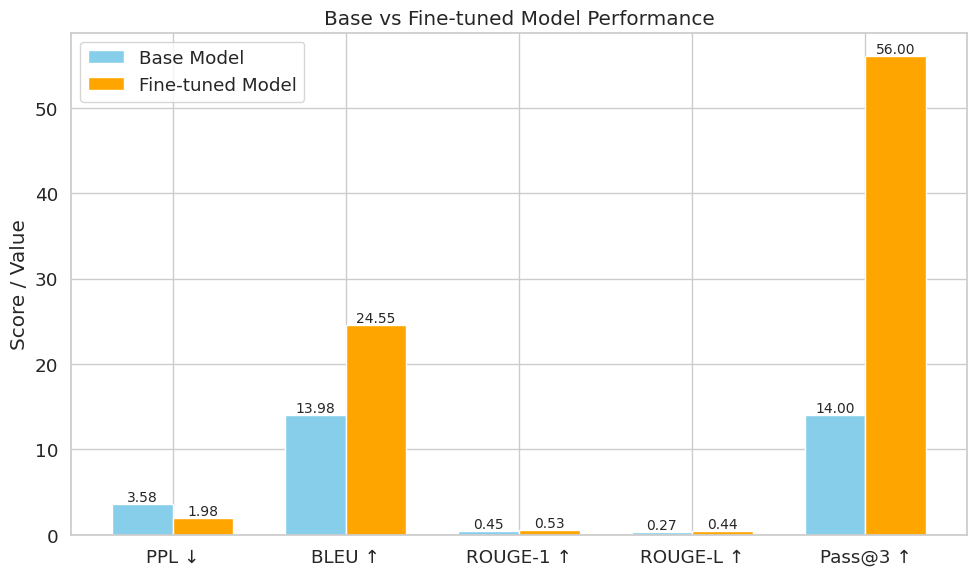

In [23]:
# Metrics data
metrics = ["PPL ↓", "BLEU ↑", "ROUGE-1 ↑", "ROUGE-L ↑", "Pass@3 ↑"]
base_values = [3.5800, 13.9831, 0.4454, 0.2718, 14.00]
finetuned_values = [1.9800, 24.5515, 0.5315, 0.4391, 56.00]

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar([i - width/2 for i in x], base_values, width, label="Base Model", color="skyblue")
plt.bar([i + width/2 for i in x], finetuned_values, width, label="Fine-tuned Model", color="orange")

# Labels and formatting
plt.xticks(x, metrics)
plt.ylabel("Score / Value")
plt.title("Base vs Fine-tuned Model Performance")
plt.legend()

# Annotate improvements
for i, (b, f) in enumerate(zip(base_values, finetuned_values)):
    plt.text(i - width/2, b + 0.01, f"{b:.2f}", ha="center", va="bottom", fontsize=10)
    plt.text(i + width/2, f + 0.01, f"{f:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2856/2658127671.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_labels, y=improvement_percentages, palette="viridis")


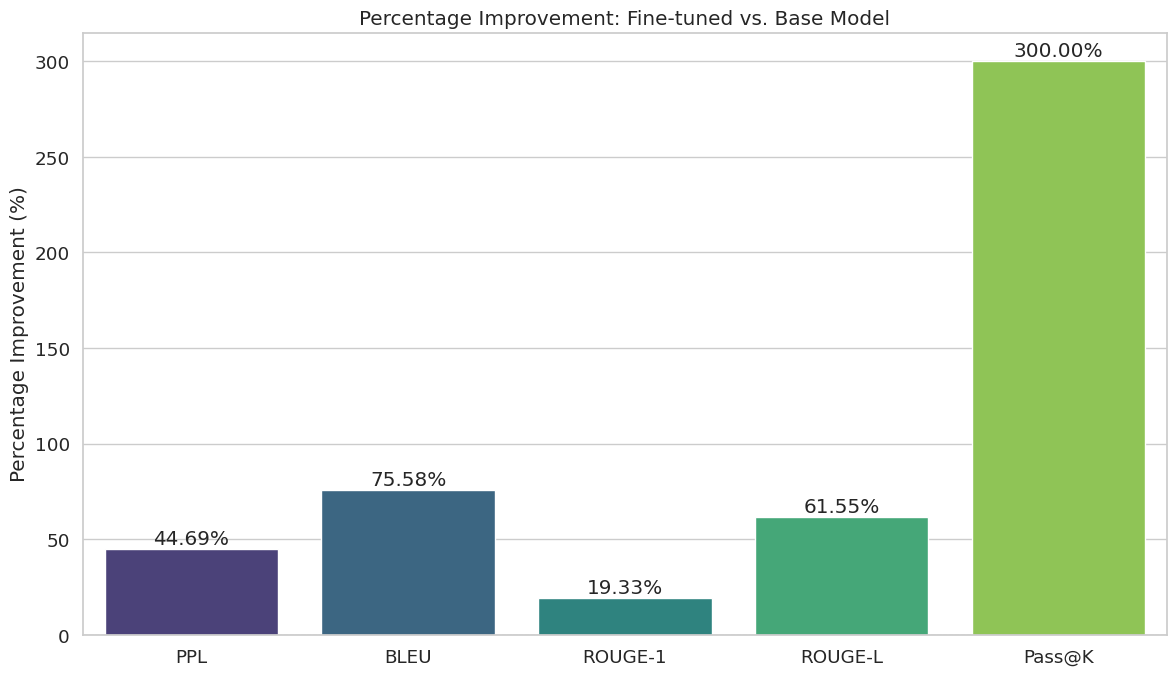

In [24]:
metric_labels = [
    "PPL",
    "BLEU",
    "ROUGE-1",
    "ROUGE-L",
    "Pass@K"
]

# Using the variables computed in previous cells for consistency
plot_data = [
    ("PPL", base_ppl, ft_ppl, True),
    ("BLEU", base_bleu, ft_bleu, False),
    ("ROUGE-1", base_r1, ft_r1, False),
    ("ROUGE-L", base_rL, ft_rL, False),
    ("Pass@K", base_pass_at_k, ft_pass_at_k, False)
]

improvement_percentages = []

for name, base_val, ft_val, lower_is_better in plot_data:
    if base_val == 0: # Avoid division by zero, though unlikely for these metrics
        improvement_percentages.append(0.0)
    else:
        if lower_is_better:
            # For metrics where lower is better (e.g., PPL), improvement means base_val is higher than ft_val
            improvement = ((base_val - ft_val) / base_val) * 100
        else:
            # For metrics where higher is better, improvement means ft_val is higher than base_val
            improvement = ((ft_val - base_val) / base_val) * 100
        improvement_percentages.append(improvement)


plt.figure(figsize=(12, 7))
sns.barplot(x=metric_labels, y=improvement_percentages, palette="viridis")

plt.ylabel("Percentage Improvement (%)")
plt.title("Percentage Improvement: Fine-tuned vs. Base Model")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference

# Annotate bars with their percentage values
for index, value in enumerate(improvement_percentages):
    plt.text(
        index,
        value + (1 if value >= 0 else -1) * 0.5, # Adjust text position slightly above/below bar
        f'{value:.2f}%',
        ha='center',
        va='bottom' if value >= 0 else 'top'
    )

plt.tight_layout()
plt.show()

### Compare Base vs Fine-Tuned Model for a specific question

In [25]:
question = "who are you"

# Prepare the prompt for the base model
base_prompt_messages = [
    {"role": "user", "content": question}
]
base_prompt = tokenizer.apply_chat_template(
    base_prompt_messages,
    tokenize=False,
    add_generation_prompt=True
)

# Prepare the prompt for the fine-tuned model (including custom system message)
ft_prompt_messages = [
    {"role": "user", "content": question}
]
ft_prompt = tokenizer.apply_chat_template(
    ft_prompt_messages,
    tokenize=False,
    add_generation_prompt=True
)

print("Generating base model response...")
base_model_response = generate(base_model, tokenizer, base_prompt)

print("Generating fine-tuned model response...")
ft_model_response = generate(ft_model, tokenizer, ft_prompt)

print("\n--- Question ---\n")
print(question)

print("\n--- Base Model Response ---\n")
print(base_model_response)

print("\n--- Fine-tuned Model Response ---\n")
print(ft_model_response)


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating base model response...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating fine-tuned model response...

--- Question ---

who are you

--- Base Model Response ---

I am Qwen, an AI developed by Alibaba Cloud. I am designed to assist with answering questions, providing information, and engaging in conversation. How can I assist you today?

--- Fine-tuned Model Response ---

I am cortex your coding assistant made by junaid


## 14. Convert Model to gguf

In [26]:
MERGED_DIR = "/content/qwen2.5-0.5b-coding-assistant-merged"

model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit"
)

print("Merged 16-bit model saved.")

config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/qwen2.5-0.5b-coding-assistant-merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:16<00:00, 16.96s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:08<00:00,  8.75s/it]


Unsloth: Merge process complete. Saved to `/content/qwen2.5-0.5b-coding-assistant-merged`
Merged 16-bit model saved.


In [27]:
!rm -rf /content/llama.cpp

!git clone https://github.com/ggerganov/llama.cpp
%cd /content/llama.cpp

!apt-get update -qq
!apt-get install -y cmake build-essential

!cmake -B build
!cmake --build build --config Release -j4

#!pip install -r requirements.txt

Cloning into 'llama.cpp'...
remote: Enumerating objects: 94405, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 94405 (delta 84), reused 55 (delta 54), pack-reused 94276 (from 3)
Receiving objects: 100% (94405/94405), 392.30 MiB | 17.68 MiB/s, done.
Resolving deltas: 100% (67133/67133), done.
/content/llama.cpp
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
0 upgraded, 0 newly installed, 0 to remove and 56 not upgraded.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C 

In [28]:
!python /content/llama.cpp/convert_hf_to_gguf.py \
    /content/qwen2.5-0.5b-coding-assistant-merged \
    --outfile /content/qwen2.5-0.5b-coding-assistant-f16.gguf \
    --outtype f16

INFO:hf-to-gguf:Loading model: qwen2.5-0.5b-coding-assistant-merged
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {896, 151936}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {896}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {4864, 896}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {896, 4864}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       torch.bfloat16 --> F16, shape = {896, 4864}
INFO:hf-to-gguf:blk.0.ffn_norm.weight,     torch.bfloat16 --> F32, shape = {896}
INFO:hf-to-gguf:blk.0.attn_k.bias,         torch.bfloat16 --> F32, shape = {128}
INFO:hf-to-gguf:blk.0.attn_k.weight,       torch.bfloat16 --> F16, s

In [29]:
!/content/llama.cpp/build/bin/llama-quantize \
    /content/qwen2.5-0.5b-coding-assistant-f16.gguf \
    /content/qwen2.5-0.5b-coding-assistant-q4_k_m.gguf \
    q4_k_m

llama_print_build_info: build = 9206 (1867a0c69)
llama_print_build_info: built with GNU 11.4.0 for Linux x86_64
main: quantizing '/content/qwen2.5-0.5b-coding-assistant-f16.gguf' to '/content/qwen2.5-0.5b-coding-assistant-q4_k_m.gguf' as Q4_K_M
llama_model_loader: loaded meta data with 24 key-value pairs and 290 tensors from /content/qwen2.5-0.5b-coding-assistant-f16.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen2
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen2.5 0.5b Coding Assistant Merged
llama_model_loader: - kv   3:                           general.finetune str              = coding-assistant-merged
llama_model_loader: - kv   4:                           gen

In [30]:
import os

files = [
    "/content/qwen2.5-0.5b-coding-assistant-f16.gguf",
    "/content/qwen2.5-0.5b-coding-assistant-q4_k_m.gguf"
]

for f in files:
    if os.path.exists(f):
        print(f"{f} -> {round(os.path.getsize(f)/(1024**3), 2)} GB")
    else:
        print(f"{f} NOT FOUND")

/content/qwen2.5-0.5b-coding-assistant-f16.gguf -> 0.93 GB
/content/qwen2.5-0.5b-coding-assistant-q4_k_m.gguf -> 0.37 GB


## 15. Push to Hugging Face Hub

In [31]:
from huggingface_hub import HfApi, logout, notebook_login

# Log out from any existing Hugging Face session
logout()

# Prompt for a new token and log in
notebook_login()

api = HfApi()

Not logged in!


In [33]:


repo_id = "junaid17/qwen2.5-0.5b-coding-assistant-gguf"

# Create the repository, if it doesn't exist already
api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True
)

# Upload the GGUF file
api.upload_file(
    path_or_fileobj="/content/qwen2.5-0.5b-coding-assistant-q4_k_m.gguf",
    path_in_repo="qwen2.5-0.5b-coding-assistant-q4_k_m.gguf",
    repo_id=repo_id,
    repo_type="model"
)

print("GGUF uploaded successfully.")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ing-assistant-q4_k_m.gguf:  22%|##1       | 86.6MB /  398MB            

GGUF uploaded successfully.
